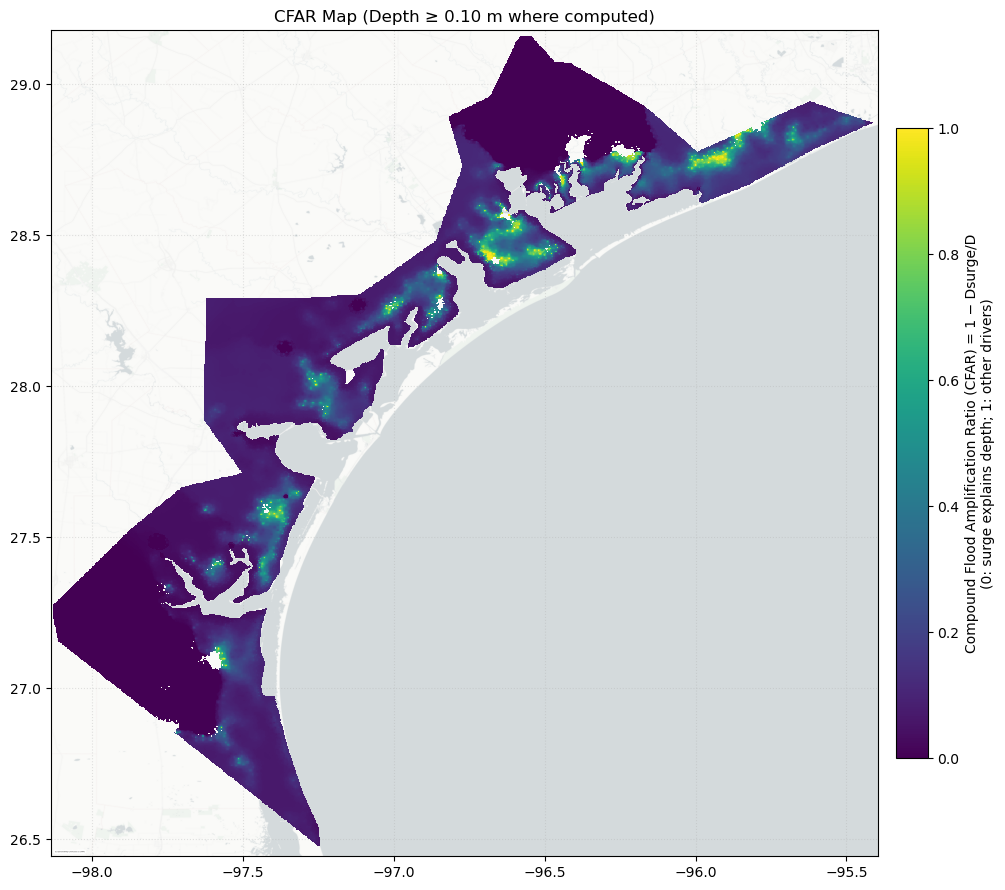

In [1]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import rasterize
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import contextily as ctx

# ---------------- USER INPUTS ----------------
r_compound = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"     # D
r_surge    = r"D:\Phd Research\Final_Raster\Inundation_only_for_Surge_100yr.tif"    # Dsurge
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"                  # land mask (UTM, zipped ok)

THRESH = 0.10             # compute CFAR only where compound depth >= THRESH (m)
DST_CRS = "EPSG:4326"     # plotting CRS
BASEMAP_ZOOM = 11
SAVE_CFAR_GEOTIFF = False # set True to write CFAR GeoTIFF beside the compound raster
# ---------------------------------------------

def read_depth(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        prof = src.profile
    return arr, prof

def ensure_boundary_gdf(zip_path):
    out_dir = os.path.splitext(zip_path)[0] + "_unzipped"
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp_files:
        raise FileNotFoundError("No .shp found in unzipped boundary.")
    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        raise ValueError("Boundary CRS is None. Set it (e.g., EPSG:32614) before running.")
    return gdf

def reproject_array_to(arr, src_prof, dst_transform, dst_crs, dst_shape, resampling=Resampling.nearest):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

# 1) Read rasters
D,  profD  = read_depth(r_compound)  # compound depth raster
Ds, profS  = read_depth(r_surge)     # surge-only depth raster

# 2) Reproject surge to the COMPOUND grid (compute CFAR on D's native grid)
Ds_on_D = np.full_like(D, np.nan, dtype=np.float32)
reproject(
    source=Ds, destination=Ds_on_D,
    src_transform=profS["transform"], src_crs=profS["crs"],
    dst_transform=profD["transform"], dst_crs=profD["crs"],
    resampling=Resampling.bilinear,    # depth surface: bilinear is fine
    src_nodata=np.nan, dst_nodata=np.nan
)

# 3) Build a land mask on D's grid using the boundary
boundary = ensure_boundary_gdf(boundary_zip)
boundary_on_D = boundary.to_crs(profD["crs"])
land_mask = rasterize(
    [(geom, 1) for geom in boundary_on_D.geometry],
    out_shape=(profD["height"], profD["width"]),
    transform=profD["transform"],
    fill=0, dtype="uint8"
).astype(bool)

# 4) Compute CFAR = 1 - Dsurge/D, with guards and clipping to [0, 1]
eps = 1e-6
valid = np.isfinite(D) & (D >= THRESH) & land_mask
CFAR = np.full_like(D, np.nan, dtype=np.float32)
CFAR[valid] = 1.0 - (np.clip(Ds_on_D[valid], 0, None) / np.maximum(D[valid], eps))
CFAR = np.clip(CFAR, 0.0, 1.0)  # negative -> 0; >1 -> 1

# Optional: save CFAR GeoTIFF in D's native CRS/grid
if SAVE_CFAR_GEOTIFF:
    out_tif = os.path.splitext(r_compound)[0] + "_CFAR.tif"
    meta = profD.copy()
    meta.update({"dtype": "float32", "count": 1, "nodata": np.nan})
    with rasterio.open(out_tif, "w", **meta) as dst:
        dst.write(CFAR, 1)
    print(f"CFAR written to: {out_tif}")

# 5) Reproject CFAR to EPSG:4326 for basemap plotting
dst_transform, dst_w, dst_h = calculate_default_transform(
    profD["crs"], DST_CRS, profD["width"], profD["height"],
    *array_bounds(profD["height"], profD["width"], profD["transform"])
)
CFAR_4326 = reproject_array_to(CFAR, profD, dst_transform, DST_CRS, (dst_h, dst_w))
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

# 6) Plot CFAR (0–1) with a transparent background for NaNs
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

# Basemap
ctx.add_basemap(
    ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
    zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1
)

# Colormap: use viridis; make NaNs transparent
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0.0)

im = ax.imshow(
    CFAR_4326, extent=[left, right, bottom, top], origin="upper",
    cmap=cmap, vmin=0.0, vmax=1.0, interpolation="nearest", zorder=3
)

# Colorbar
cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Compound Flood Amplification Ratio (CFAR) = 1 − Dsurge/D\n(0: surge explains depth; 1: other drivers)")

ax.set_title(f"CFAR Map (Depth ≥ {THRESH:.2f} m where computed)")
ax.set_aspect("equal")
ax.grid(True, linestyle=":", alpha=0.35)

plt.tight_layout()
plt.show()


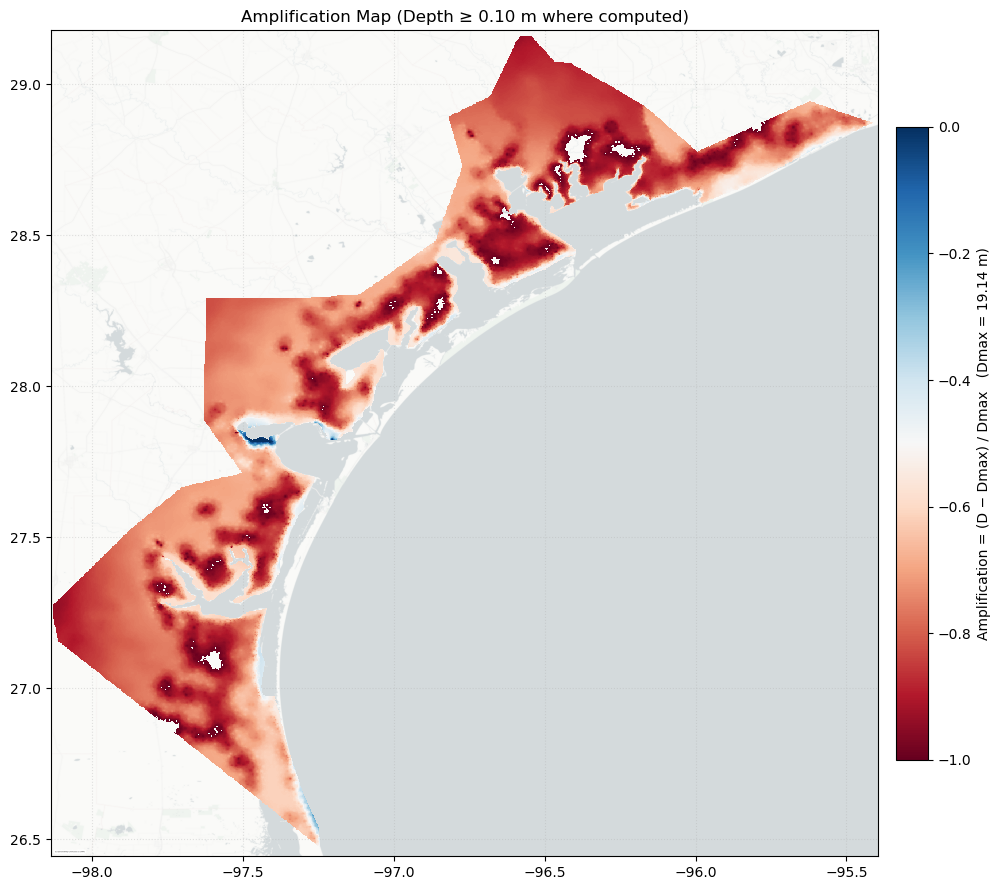

In [2]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import contextily as ctx

# ---------------- USER INPUTS ----------------
r_compound   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"  # D
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"                 # land (UTM, zipped ok)

THRESH = 0.10            # compute only where D >= THRESH (m)
DST_CRS = "EPSG:4326"    # plotting CRS
BASEMAP_ZOOM = 11
SAVE_GEOTIFF = False     # True to write GeoTIFF beside the compound raster
DMAX = 19.14             # max depth among single drivers (constant, meters)
# ---------------------------------------------

def read_depth(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        prof = src.profile
    return arr, prof

def ensure_boundary_gdf(zip_path):
    out_dir = os.path.splitext(zip_path)[0] + "_unzipped"
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp_files:
        raise FileNotFoundError("No .shp found in unzipped boundary.")
    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        raise ValueError("Boundary CRS is None. Set it (e.g., EPSG:32614).")
    return gdf

def reproject_array_to(arr, src_prof, dst_transform, dst_crs, dst_shape, resampling=Resampling.nearest):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

# 1) Read compound depth raster (D)
D, profD = read_depth(r_compound)

# 2) Land mask on D's grid
boundary = ensure_boundary_gdf(boundary_zip)
boundary_on_D = boundary.to_crs(profD["crs"])
land_mask = rasterize(
    [(geom, 1) for geom in boundary_on_D.geometry],
    out_shape=(profD["height"], profD["width"]),
    transform=profD["transform"],
    fill=0, dtype="uint8"
).astype(bool)

# 3) Amplification metric: A = (D - Dmax)/Dmax  (compute where valid & on land & D>=THRESH)
valid = np.isfinite(D) & (D >= THRESH) & land_mask
A = np.full_like(D, np.nan, dtype=np.float32)
A[valid] = (D[valid] - DMAX) / DMAX
# (optional) clip to [-1, 0] if you know D ≤ DMAX everywhere:
# A = np.clip(A, -1.0, 0.0)

# 4) Optionally save GeoTIFF
if SAVE_GEOTIFF:
    out_tif = os.path.splitext(r_compound)[0] + "_Amplification.tif"
    meta = profD.copy()
    meta.update({"dtype": "float32", "count": 1, "nodata": np.nan})
    with rasterio.open(out_tif, "w", **meta) as dst:
        dst.write(A, 1)
    print(f"Wrote: {out_tif}")

# 5) Reproject to EPSG:4326 for plotting
dst_transform, dst_w, dst_h = calculate_default_transform(
    profD["crs"], DST_CRS, profD["width"], profD["height"],
    *array_bounds(profD["height"], profD["width"], profD["transform"])
)
A_4326 = reproject_array_to(A, profD, dst_transform, DST_CRS, (dst_h, dst_w))
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

# 6) Plot
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1)

# Use a diverging palette, showing 0 (no amplification vs Dmax) to -1 (much less than Dmax)
cmap = plt.cm.RdBu  # negative → blue, 0 → white
cmap = cmap.copy(); cmap.set_bad(alpha=0.0)

im = ax.imshow(
    A_4326, extent=[left, right, bottom, top], origin="upper",
    cmap=cmap, vmin=-1.0, vmax=0.0, interpolation="nearest", zorder=3
)

cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label(f"Amplification = (D − Dmax) / Dmax   (Dmax = {DMAX:.2f} m)")

ax.set_title(f"Amplification Map (Depth ≥ {THRESH:.2f} m where computed)")
ax.set_aspect("equal"); ax.grid(True, linestyle=":", alpha=0.35)

plt.tight_layout(); plt.show()


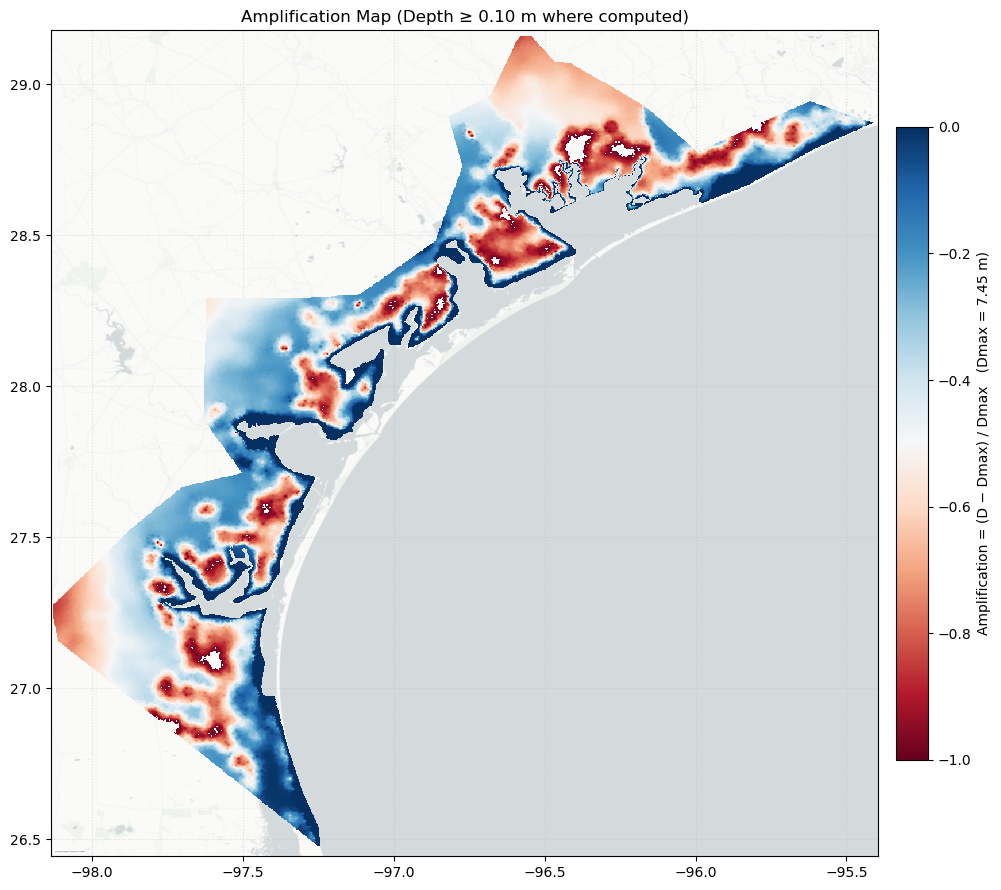

In [3]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import contextily as ctx

# ---------------- USER INPUTS ----------------
r_compound   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"  # D
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"                 # land (UTM, zipped ok)

THRESH = 0.10            # compute only where D >= THRESH (m)
DST_CRS = "EPSG:4326"    # plotting CRS
BASEMAP_ZOOM = 11
SAVE_GEOTIFF = False     # True to write GeoTIFF beside the compound raster
DMAX = 7.45             # max depth among single drivers (constant, meters)
# ---------------------------------------------

def read_depth(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        prof = src.profile
    return arr, prof

def ensure_boundary_gdf(zip_path):
    out_dir = os.path.splitext(zip_path)[0] + "_unzipped"
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp_files:
        raise FileNotFoundError("No .shp found in unzipped boundary.")
    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        raise ValueError("Boundary CRS is None. Set it (e.g., EPSG:32614).")
    return gdf

def reproject_array_to(arr, src_prof, dst_transform, dst_crs, dst_shape, resampling=Resampling.nearest):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

# 1) Read compound depth raster (D)
D, profD = read_depth(r_compound)

# 2) Land mask on D's grid
boundary = ensure_boundary_gdf(boundary_zip)
boundary_on_D = boundary.to_crs(profD["crs"])
land_mask = rasterize(
    [(geom, 1) for geom in boundary_on_D.geometry],
    out_shape=(profD["height"], profD["width"]),
    transform=profD["transform"],
    fill=0, dtype="uint8"
).astype(bool)

# 3) Amplification metric: A = (D - Dmax)/Dmax  (compute where valid & on land & D>=THRESH)
valid = np.isfinite(D) & (D >= THRESH) & land_mask
A = np.full_like(D, np.nan, dtype=np.float32)
A[valid] = (D[valid] - DMAX) / DMAX
# (optional) clip to [-1, 0] if you know D ≤ DMAX everywhere:
# A = np.clip(A, -1.0, 0.0)

# 4) Optionally save GeoTIFF
if SAVE_GEOTIFF:
    out_tif = os.path.splitext(r_compound)[0] + "_Amplification.tif"
    meta = profD.copy()
    meta.update({"dtype": "float32", "count": 1, "nodata": np.nan})
    with rasterio.open(out_tif, "w", **meta) as dst:
        dst.write(A, 1)
    print(f"Wrote: {out_tif}")

# 5) Reproject to EPSG:4326 for plotting
dst_transform, dst_w, dst_h = calculate_default_transform(
    profD["crs"], DST_CRS, profD["width"], profD["height"],
    *array_bounds(profD["height"], profD["width"], profD["transform"])
)
A_4326 = reproject_array_to(A, profD, dst_transform, DST_CRS, (dst_h, dst_w))
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

# 6) Plot
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1)

# Use a diverging palette, showing 0 (no amplification vs Dmax) to -1 (much less than Dmax)
cmap = plt.cm.RdBu  # negative → blue, 0 → white
cmap = cmap.copy(); cmap.set_bad(alpha=0.0)

im = ax.imshow(
    A_4326, extent=[left, right, bottom, top], origin="upper",
    cmap=cmap, vmin=-1.0, vmax=0.0, interpolation="nearest", zorder=3
)

cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label(f"Amplification = (D − Dmax) / Dmax   (Dmax = {DMAX:.2f} m)")

ax.set_title(f"Amplification Map (Depth ≥ {THRESH:.2f} m where computed)")
ax.set_aspect("equal"); ax.grid(True, linestyle=":", alpha=0.35)

plt.tight_layout(); plt.show()


C:\Users\sahad2\AppData\Local\Temp\ipykernel_21908\1841400618.py:86: RuntimeWarning: All-NaN slice encountered
  Dmax = np.nanmax(stack, axis=0)


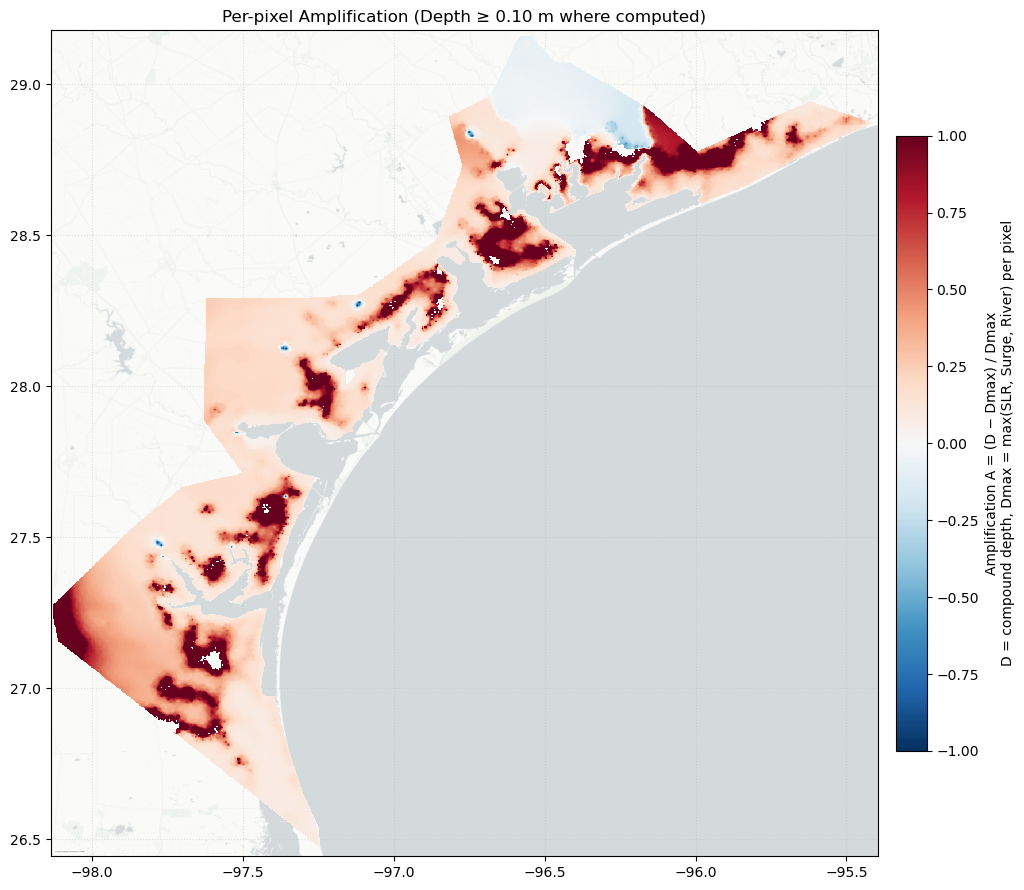

In [4]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import contextily as ctx

# ---------------- USER INPUTS ----------------
r_compound   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"   # D (compound)
r_slr_only   = r"D:\Phd Research\Final_Raster\Inundation_only_for_SLR.tif"          # SLR-only
r_surge_only = r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr_v1_stat.tif"  # Surge-only
r_q_only     = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"               # River-only

# Optional land boundary (zipped shapefile). If missing, the script will skip land masking.
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

THRESH        = 0.10          # compute only where D >= THRESH (m)
DST_CRS       = "EPSG:4326"   # plotting CRS
BASEMAP_ZOOM  = 11
SAVE_GEOTIFF  = False         # True to export A as GeoTIFF on the compound grid
VMIN, VMAX    = -1.0, 1.0     # color range for A (negative = D < Dmax, positive = amplification)
# ---------------------------------------------

def read_depth(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        # treat negative depths as invalid
        arr = np.where(arr < 0, np.nan, arr)
        prof = src.profile
    return arr, prof

def reproject_array_to(arr, src_prof, dst_prof, resampling=Resampling.bilinear):
    dst = np.full((dst_prof["height"], dst_prof["width"]), np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_prof["transform"], dst_crs=dst_prof["crs"],
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

def try_land_mask(zip_path, target_prof):
    """Return boolean land mask rasterized on target profile grid; or None if zip missing."""
    if not (zip_path and os.path.exists(zip_path)):
        return None
    out_dir = os.path.splitext(zip_path)[0] + "_unzipped"
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(out_dir)
    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp_files:
        return None
    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        return None
    gdf = gdf.to_crs(target_prof["crs"])
    land = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(target_prof["height"], target_prof["width"]),
        transform=target_prof["transform"],
        fill=0, dtype="uint8"
    ).astype(bool)
    return land

# 1) Read compound (reference grid) and single-driver rasters
D, profD = read_depth(r_compound)
SLR,  prof_slr   = read_depth(r_slr_only)
SURG, prof_surge = read_depth(r_surge_only)
Q,    prof_q     = read_depth(r_q_only)

# 2) Put all single-driver depths on the compound grid
SLR_on_D  = reproject_array_to(SLR,  prof_slr,   profD, resampling=Resampling.bilinear)
SURG_on_D = reproject_array_to(SURG, prof_surge, profD, resampling=Resampling.bilinear)
Q_on_D    = reproject_array_to(Q,    prof_q,     profD, resampling=Resampling.bilinear)

# 3) Per-pixel Dmax = max(SLR, Surge, River) ignoring NaNs
stack = np.stack([SLR_on_D, SURG_on_D, Q_on_D], axis=0)
Dmax = np.nanmax(stack, axis=0)

# 4) Valid mask and amplification A = (D - Dmax)/Dmax
eps = 1e-6
valid = np.isfinite(D) & np.isfinite(Dmax) & (D >= THRESH) & (Dmax > eps)

# Optional land mask (if boundary zip is available)
land_mask = try_land_mask(boundary_zip, profD)
if land_mask is not None:
    valid &= land_mask

A = np.full_like(D, np.nan, dtype=np.float32)
A[valid] = (D[valid] - Dmax[valid]) / Dmax[valid]

# 5) (Optional) Save GeoTIFF of A on the compound grid
if SAVE_GEOTIFF:
    out_tif = os.path.splitext(r_compound)[0] + "_Amplification_perPixelDmax.tif"
    meta = profD.copy()
    meta.update({"dtype": "float32", "count": 1, "nodata": np.nan})
    with rasterio.open(out_tif, "w", **meta) as dst:
        dst.write(A, 1)
    print(f"Wrote: {out_tif}")

# 6) Reproject A to EPSG:4326 and plot over a basemap
dst_transform, dst_w, dst_h = calculate_default_transform(
    profD["crs"], DST_CRS, profD["width"], profD["height"],
    *array_bounds(profD["height"], profD["width"], profD["transform"])
)
A_4326 = np.full((dst_h, dst_w), np.nan, dtype=np.float32)
reproject(
    source=A, destination=A_4326,
    src_transform=profD["transform"], src_crs=profD["crs"],
    dst_transform=dst_transform,     dst_crs=DST_CRS,
    resampling=Resampling.bilinear,
    src_nodata=np.nan, dst_nodata=np.nan
)
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(left, right); ax.set_ylim(bottom, top)
ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1)

# Diverging colormap (negative = attenuation, positive = amplification)
cmap = plt.cm.RdBu_r.copy()  # blue for negative, red for positive
cmap.set_bad(alpha=0.0)

im = ax.imshow(A_4326, extent=[left, right, bottom, top], origin="upper",
               cmap=cmap, vmin=VMIN, vmax=VMAX, interpolation="nearest", zorder=3)

cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Amplification A = (D − Dmax) / Dmax\n"
             "D = compound depth, Dmax = max(SLR, Surge, River) per pixel")

ax.set_title(f"Per-pixel Amplification (Depth ≥ {THRESH:.2f} m where computed)")
ax.set_aspect("equal"); ax.grid(True, linestyle=":", alpha=0.35)
plt.tight_layout(); plt.show()

# # Quick textual summary (optional)
# valid_A = np.isfinite(A)
# if np.any(valid_A):
#     pct_amp = 100.0 * np.count_nonzero(A[valid_A] > 0) / np.count_nonzero(valid_A)
#     print(f"Pixels with amplification (A>0): {pct_amp:.1f}% of evaluated pixels.")


Wrote: D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat_Amplification_perPixelSUM.tif


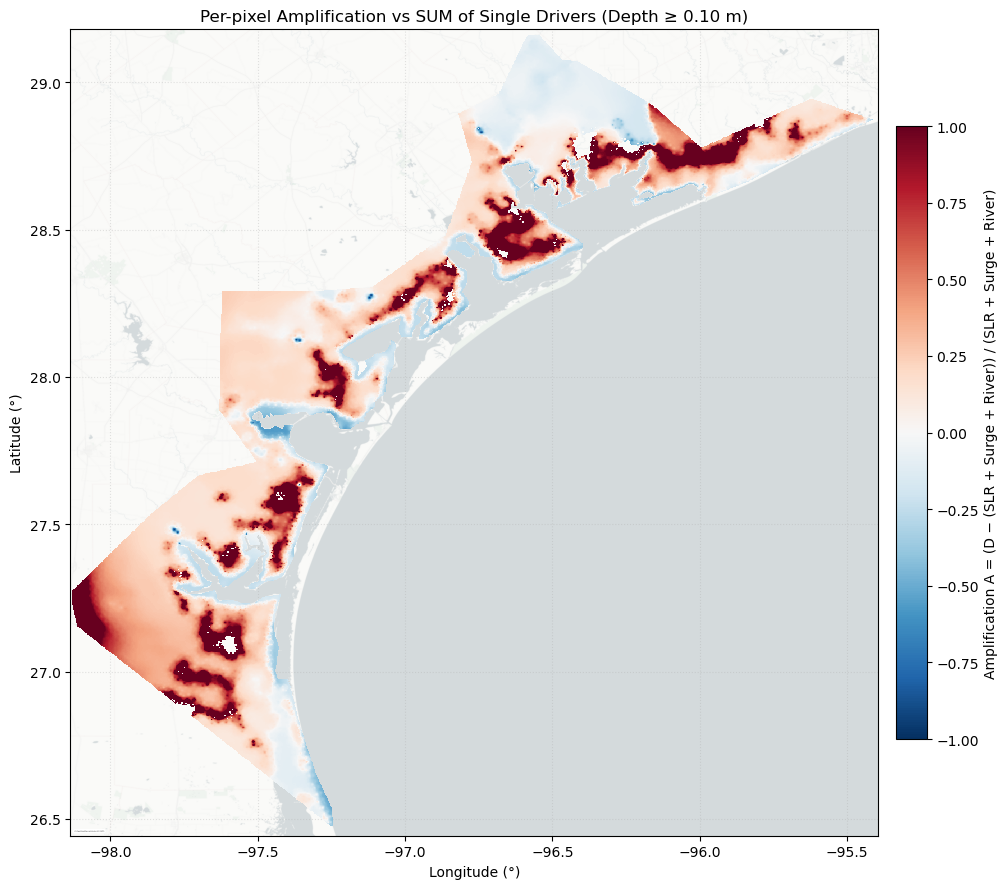

In [7]:
import os, zipfile
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
from rasterio.features import rasterize
import matplotlib.pyplot as plt
import contextily as ctx

# ---------------- USER INPUTS ----------------
r_compound   = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"   # D (compound)
r_slr_only   = r"D:\Phd Research\Final_Raster\Inundation_only_for_SLR.tif"          # SLR-only
r_surge_only = r"D:\Phd Research\Final_Raster\inundation for only storm surge 100 yr_v1_stat.tif"  # Surge-only
r_q_only     = r"D:\Phd Research\Final_Raster\100yr_Q_flood_only.tif"               # River-only

# Optional land boundary (zipped shapefile). If missing, the script will skip land masking.
boundary_zip = r"D:\Phd Research\GIS\Shape\land_Part_area_utm.zip"

THRESH        = 0.10          # compute only where D >= THRESH (m)
DST_CRS       = "EPSG:4326"   # plotting CRS (lat/long on axes)
BASEMAP_ZOOM  = 11
SAVE_GEOTIFF  = True         # True to export A as GeoTIFF on the compound grid
VMIN, VMAX    = -1.0, 1.0     # color range for A (negative = D < sum, positive = amplification)
# ---------------------------------------------

def read_depth(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        nod = src.nodata
        if nod is not None:
            arr = np.where(arr == nod, np.nan, arr)
        # treat negative depths as invalid
        arr = np.where(arr < 0, np.nan, arr)
        prof = src.profile
    return arr, prof

def reproject_array_to(arr, src_prof, dst_prof, resampling=Resampling.bilinear):
    dst = np.full((dst_prof["height"], dst_prof["width"]), np.nan, dtype=np.float32)
    reproject(
        source=arr, destination=dst,
        src_transform=src_prof["transform"], src_crs=src_prof["crs"],
        dst_transform=dst_prof["transform"], dst_crs=dst_prof["crs"],
        resampling=resampling,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

def try_land_mask(zip_path, target_prof):
    """Return boolean land mask rasterized on target profile grid; or None if zip missing."""
    if not (zip_path and os.path.exists(zip_path)):
        return None
    out_dir = os.path.splitext(zip_path)[0] + "_unzipped"
    if not os.path.isdir(out_dir) or not any(f.endswith(".shp") for f in os.listdir(out_dir)):
        os.makedirs(out_dir, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(out_dir)
    shp_files = [os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith(".shp")]
    if not shp_files:
        return None
    gdf = gpd.read_file(shp_files[0])
    if gdf.crs is None:
        return None
    gdf = gdf.to_crs(target_prof["crs"])
    land = rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=(target_prof["height"], target_prof["width"]),
        transform=target_prof["transform"],
        fill=0, dtype="uint8"
    ).astype(bool)
    return land

# ---------------- LOAD RASTERS ----------------
D, profD = read_depth(r_compound)
SLR,  prof_slr   = read_depth(r_slr_only)
SURG, prof_surge = read_depth(r_surge_only)
Q,    prof_q     = read_depth(r_q_only)

# Align single-driver rasters to the compound grid
SLR_on_D  = reproject_array_to(SLR,  prof_slr,   profD, resampling=Resampling.bilinear)
SURG_on_D = reproject_array_to(SURG, prof_surge, profD, resampling=Resampling.bilinear)
Q_on_D    = reproject_array_to(Q,    prof_q,     profD, resampling=Resampling.bilinear)

# ------------- Dmax as SUM (per-pixel) -------------
# Treat missing single-driver values as zero in the sum
stack = np.stack([SLR_on_D, SURG_on_D, Q_on_D], axis=0)
# Replace NaNs with 0 for summation only
stack_for_sum = np.where(np.isnan(stack), 0.0, stack)
Dmax = np.sum(stack_for_sum, axis=0)

# ------------- VALID MASK + AMPLIFICATION -------------
eps = 1e-6
valid = np.isfinite(D) & np.isfinite(Dmax) & (D >= THRESH) & (Dmax > eps)

# Optional land mask
land_mask = try_land_mask(boundary_zip, profD)
if land_mask is not None:
    valid &= land_mask

A = np.full_like(D, np.nan, dtype=np.float32)
A[valid] = (D[valid] - Dmax[valid]) / Dmax[valid]

# ------------- OPTIONAL: SAVE GEOTIFF -------------
if SAVE_GEOTIFF:
    out_tif = os.path.splitext(r_compound)[0] + "_Amplification_perPixelSUM.tif"
    meta = profD.copy()
    meta.update({"dtype": "float32", "count": 1, "nodata": np.nan})
    with rasterio.open(out_tif, "w", **meta) as dst:
        dst.write(A, 1)
    print(f"Wrote: {out_tif}")

# ------------- REPROJECT TO 4326 FOR PLOTTING -------------
dst_transform, dst_w, dst_h = calculate_default_transform(
    profD["crs"], DST_CRS, profD["width"], profD["height"],
    *array_bounds(profD["height"], profD["width"], profD["transform"])
)
A_4326 = np.full((dst_h, dst_w), np.nan, dtype=np.float32)
reproject(
    source=A, destination=A_4326,
    src_transform=profD["transform"], src_crs=profD["crs"],
    dst_transform=dst_transform,     dst_crs=DST_CRS,
    resampling=Resampling.bilinear,
    src_nodata=np.nan, dst_nodata=np.nan
)
left, bottom, right, top = array_bounds(dst_h, dst_w, dst_transform)

# ------------- PLOT -------------
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(left, right); ax.set_ylim(bottom, top)

# Basemap (axes in lat/long)
ctx.add_basemap(ax, crs=DST_CRS, source=ctx.providers.CartoDB.PositronNoLabels,
                zoom=BASEMAP_ZOOM, attribution_size=0, zorder=1)

# Diverging colormap (blue: attenuation, red: amplification)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(alpha=0.0)

im = ax.imshow(A_4326, extent=[left, right, bottom, top], origin="upper",
               cmap=cmap, vmin=VMIN, vmax=VMAX, interpolation="nearest", zorder=3)

cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("Amplification A = (D − (SLR + Surge + River)) / (SLR + Surge + River)")

ax.set_title(f"Per-pixel Amplification vs SUM of Single Drivers (Depth ≥ {THRESH:.2f} m)")
ax.set_aspect("equal"); ax.grid(True, linestyle=":", alpha=0.35)
ax.set_xlabel("Longitude (°)"); ax.set_ylabel("Latitude (°)")
plt.tight_layout(); plt.show()

# ------------- QUICK SUMMARY -------------
valid_A = np.isfinite(A)
if np.any(valid_A):
    n_eval = np.count_nonzero(valid_A)
    pct_amp = 100.0 * np.count_nonzero(A[valid_A] > 0) / n_eval
    pct_att = 100.0 * np.count_nonzero(A[valid_A] < 0) / n_eval
    # print(f"Evaluated pixels: {n_eval:,}")
    # print(f"Amplification (A>0): {pct_amp:.1f}%   Attenuation (A<0): {pct_att:.1f}%")
else:
    print("No valid pixels met the criteria (check THRESH / inputs).")
